In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
df = sns.load_dataset("titanic")
print("dataset loaded succesfully!!")

dataset loaded succesfully!!


In [ ]:
# Calculate missing percentages
missing_percentage = df.isnull().mean() * 100

# Less than 5% → drop rows
low_missing_cols = missing_percentage[
    (missing_percentage > 0) & (missing_percentage < 5)
].index

df = df.dropna(subset=low_missing_cols)

# 5%–30% → impute
medium_missing_cols = missing_percentage[
    (missing_percentage >= 5) & (missing_percentage <= 30)
].index

for column in medium_missing_cols:
    if df[column].dtype == "object":
        df[column] = df[column].fillna(df[column].mode()[0])
    else:
        df[column] = df[column].fillna(df[column].median())

# Very high missingness → drop column
high_missing_cols = missing_percentage[
    missing_percentage > 30
].index

df = df.drop(columns=high_missing_cols)

print("Cleaned dataset shape:", df.shape)
print("\nRemaining missing values:")
print(df.isnull().sum())

Cleaned dataset shape: (889, 14)

Remaining missing values:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


In [ ]:
df.to_csv("titanic.csv", index=False)

print("Original Titanic dataset saved as titanic.csv")

Original Titanic dataset saved as titanic.csv


# TASK7

In [ ]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=["survived"])
y = df["survived"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nOverall survival distribution:")
print(y.value_counts(normalize=True))

print("\nTraining survival distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting survival distribution:")
print(y_test.value_counts(normalize=True))

Training set: (711, 13)
Testing set: (178, 13)

Overall survival distribution:
survived
0    0.617548
1    0.382452
Name: proportion, dtype: float64

Training survival distribution:
survived
0    0.61744
1    0.38256
Name: proportion, dtype: float64

Testing survival distribution:
survived
0    0.617978
1    0.382022
Name: proportion, dtype: float64


# TASK8

In [ ]:
# Features to use for modeling
features = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked"
]

X = df[features]
y = df["survived"]

print("Features:")
print(X.columns.tolist())

print("\nShape:", X.shape)

Features:
['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']

Shape: (889, 7)


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Numerical columns
numeric_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

# Categorical columns
categorical_features = [
    "sex",
    "embarked"
]

# Numerical preprocessing
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine both
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [ ]:
# Fit preprocessing ONLY on training data
X_train_processed = preprocessor.fit_transform(X_train[features])

# Transform test data using the already-fitted preprocessing
X_test_processed = preprocessor.transform(X_test[features])

print("Training data shape after preprocessing:", X_train_processed.shape)
print("Testing data shape after preprocessing:", X_test_processed.shape)

Training data shape after preprocessing: (711, 10)
Testing data shape after preprocessing: (178, 10)


# TASK9

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

# Logistic Regression
logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

# Decision Tree
tree_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        random_state=42
    ))
])

# Random Forest
forest_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        random_state=42
    ))
])

print("All three pipelines created.")

All three pipelines created.


In [ ]:
# Train Logistic Regression
logistic_pipeline.fit(X_train[features], y_train)

# Train Decision Tree
tree_pipeline.fit(X_train[features], y_train)

# Train Random Forest
forest_pipeline.fit(X_train[features], y_train)

print("All three models trained successfully.")

All three models trained successfully.


In [ ]:
# Predictions on the same test set
y_pred_logistic = logistic_pipeline.predict(X_test[features])
y_pred_tree = tree_pipeline.predict(X_test[features])
y_pred_forest = forest_pipeline.predict(X_test[features])

print("Predictions generated successfully.")

Predictions generated successfully.


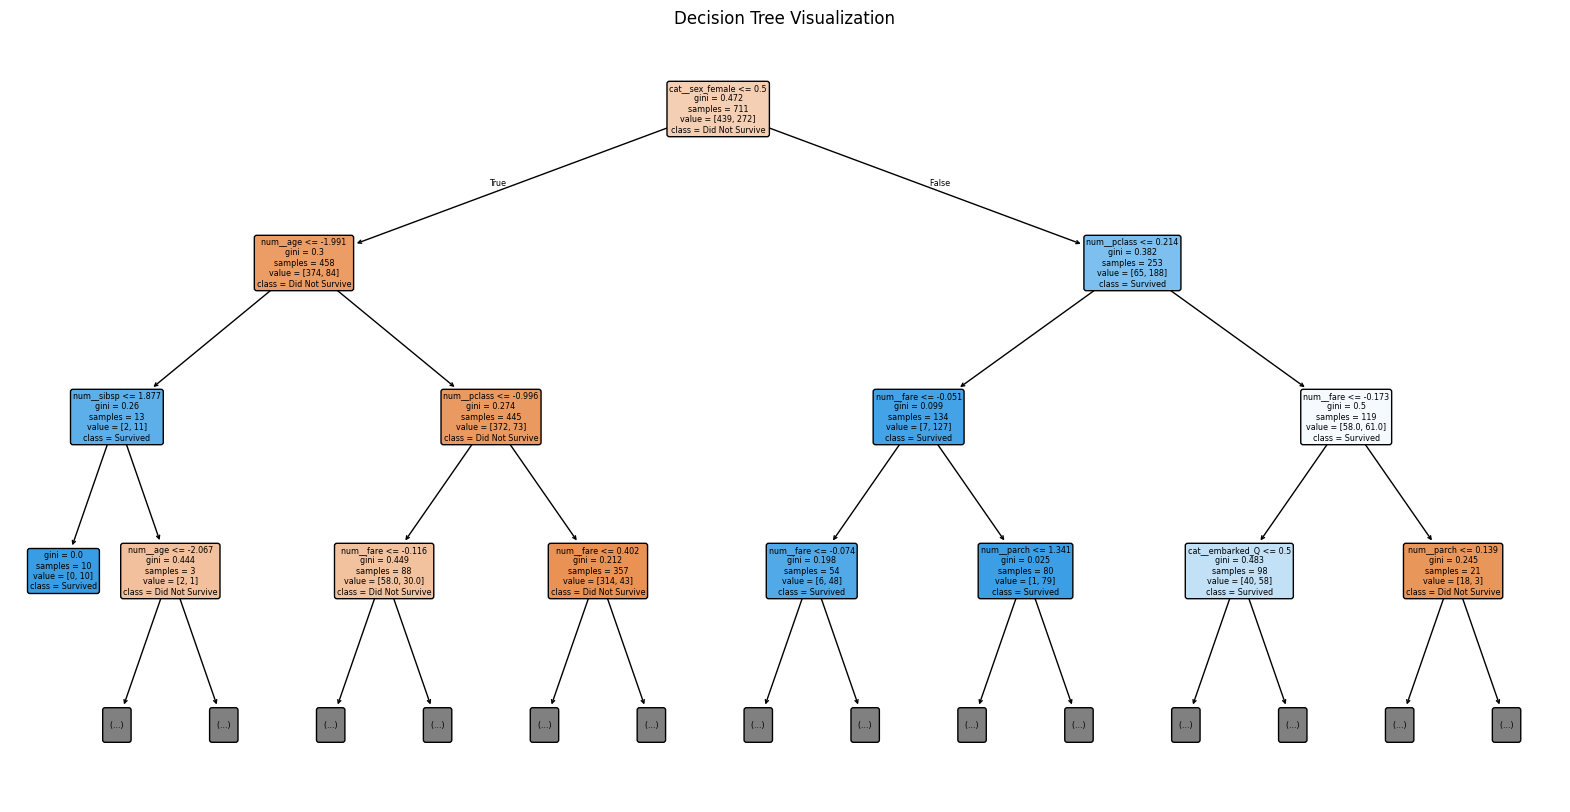

In [ ]:
from sklearn.tree import plot_tree

# Get transformed feature names
feature_names = (
    tree_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

# Get the trained decision tree
decision_tree = tree_pipeline.named_steps["classifier"]

plt.figure(figsize=(20, 10))

plot_tree(
    decision_tree,
    feature_names=feature_names,
    class_names=["Did Not Survive", "Survived"],
    filled=True,
    rounded=True,
    max_depth=3
)

plt.title("Decision Tree Visualization")
plt.show()

# TASK10

In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

models = {
    "Logistic Regression": logistic_pipeline,
    "Decision Tree": tree_pipeline,
    "Random Forest": forest_pipeline
}

predictions = {
    "Logistic Regression": y_pred_logistic,
    "Decision Tree": y_pred_tree,
    "Random Forest": y_pred_forest
}

results = []

for name, model in models.items():
    y_pred = predictions[name]

    # Probability for ROC/AUC
    y_prob = model.predict_proba(X_test[features])[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)

display(results_df)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.808989,0.783333,0.691176,0.734375,0.860963
1,Decision Tree,0.769663,0.690141,0.720588,0.705036,0.754144
2,Random Forest,0.820225,0.781250,0.735294,0.757576,0.817914


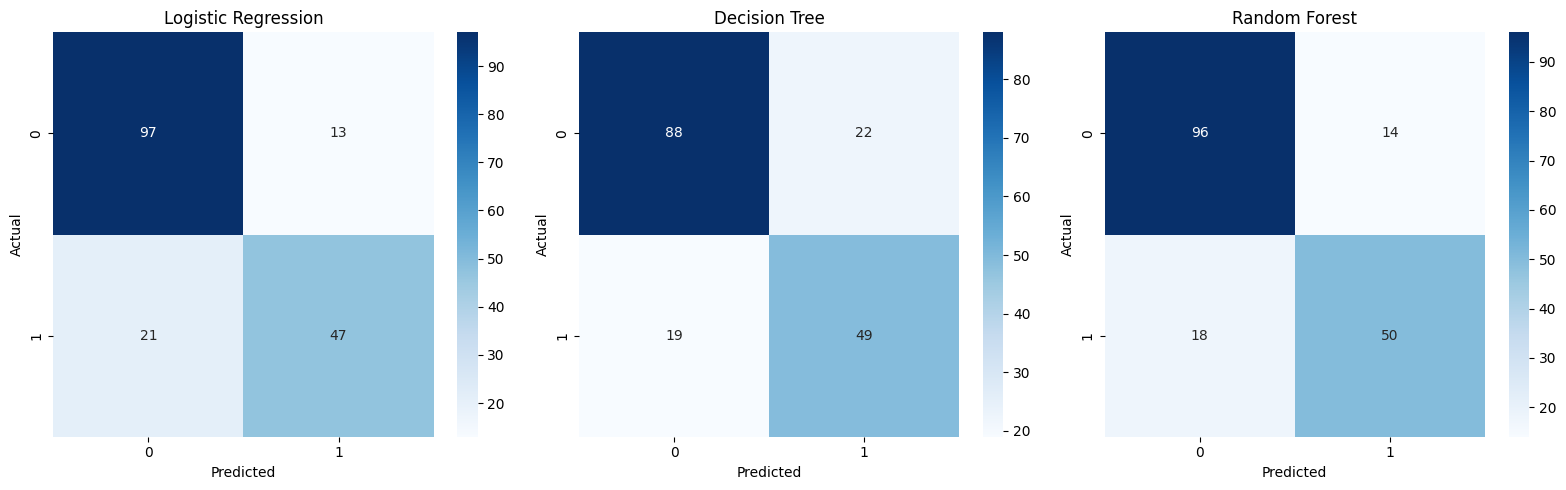

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, y_pred) in zip(axes, predictions.items()):

    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax
    )

    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

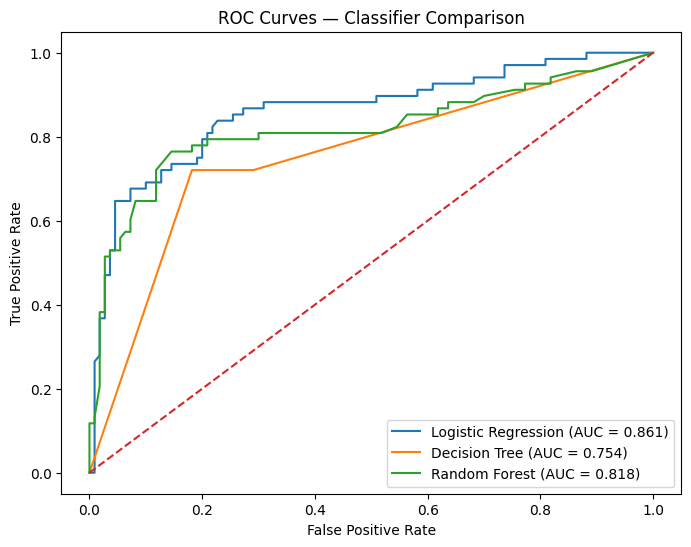

In [ ]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test[features])[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Classifier Comparison")
plt.legend()
plt.show()

# TASK11

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

print("Class distribution:")
print(y_train.value_counts())
print("\nClass proportions:")
print(y_train.value_counts(normalize=True))


# ---------- 1. BASELINE ----------
baseline_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        random_state=42
    ))
])

baseline_pipeline.fit(X_train[features], y_train)

baseline_pred = baseline_pipeline.predict(X_test[features])


# ---------- 2. CLASS WEIGHT = BALANCED ----------
balanced_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        class_weight="balanced",
        random_state=42
    ))
])

balanced_pipeline.fit(X_train[features], y_train)

balanced_pred = balanced_pipeline.predict(X_test[features])


# ---------- 3. SMOTE ----------
# First preprocess training and test data
X_train_processed = preprocessor.fit_transform(X_train[features])
X_test_processed = preprocessor.transform(X_test[features])

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

print("\nClass distribution after SMOTE:")
print(pd.Series(y_train_smote).value_counts())

smote_model = RandomForestClassifier(random_state=42)

smote_model.fit(X_train_smote, y_train_smote)

smote_pred = smote_model.predict(X_test_processed)

Class distribution:
survived
0    439
1    272
Name: count, dtype: int64

Class proportions:
survived
0    0.61744
1    0.38256
Name: proportion, dtype: float64

Class distribution after SMOTE:
survived
1    439
0    439
Name: count, dtype: int64


In [ ]:
imbalance_results = pd.DataFrame({
    "Strategy": [
        "Baseline",
        "Class Weight Balanced",
        "SMOTE"
    ],
    "Precision": [
        precision_score(y_test, baseline_pred),
        precision_score(y_test, balanced_pred),
        precision_score(y_test, smote_pred)
    ],
    "Recall": [
        recall_score(y_test, baseline_pred),
        recall_score(y_test, balanced_pred),
        recall_score(y_test, smote_pred)
    ],
    "F1": [
        f1_score(y_test, baseline_pred),
        f1_score(y_test, balanced_pred),
        f1_score(y_test, smote_pred)
    ]
})

display(imbalance_results)

,Strategy,Precision,Recall,F1
0,Baseline,0.781250,0.735294,0.757576
1,Class Weight Balanced,0.769231,0.735294,0.751880
2,SMOTE,0.746032,0.691176,0.717557


# TASK12

In [ ]:
from sklearn.model_selection import GridSearchCV

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        random_state=42,
        oob_score=True
    ))
])

param_grid = {
    "classifier__n_estimators": [50, 100, 200],
    "classifier__max_depth": [None, 5, 10],
    "classifier__max_features": ["sqrt", "log2"]
}

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train[features], y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F1:")
print(grid_search.best_score_)

Best Parameters:
{'classifier__max_depth': 5, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 200}

Best Cross-Validation F1:
0.7408312771917277


In [ ]:
best_rf_pipeline = grid_search.best_estimator_

best_rf = best_rf_pipeline.named_steps["classifier"]

print("OOB Score:")
print(best_rf.oob_score_)

OOB Score:
0.8213783403656821


# TASK13

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Features for predicting fare
reg_features = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "embarked"
]

X_reg = df[reg_features]
y_reg = df["fare"]

# Train-test split
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

# Preprocessing
reg_numeric = ["pclass", "age", "sibsp", "parch"]
reg_categorical = ["sex", "embarked"]

reg_preprocessor = ColumnTransformer([
    (
        "num",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]),
        reg_numeric
    ),
    (
        "cat",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]),
        reg_categorical
    )
])

regression_pipeline = Pipeline([
    ("preprocessor", reg_preprocessor),
    ("regressor", LinearRegression())
])

regression_pipeline.fit(X_reg_train, y_reg_train)

fare_pred = regression_pipeline.predict(X_reg_test)

mae = mean_absolute_error(y_reg_test, fare_pred)
rmse = np.sqrt(mean_squared_error(y_reg_test, fare_pred))
r2 = r2_score(y_reg_test, fare_pred)

# Adjusted R²
n = len(y_reg_test)
p = regression_pipeline.named_steps[
    "preprocessor"
].transform(X_reg_test).shape[1]

adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)
print("Adjusted R²:", adjusted_r2)

MAE: 21.138552296883095
RMSE: 41.746502315739114
R²: 0.34677389181134044
Adjusted R²: 0.3117796360155194


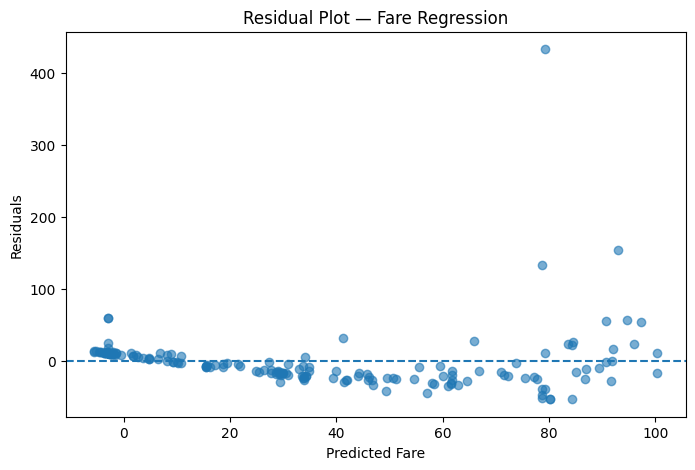

In [ ]:
residuals = y_reg_test - fare_pred

plt.figure(figsize=(8, 5))

plt.scatter(fare_pred, residuals, alpha=0.6)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")
plt.title("Residual Plot — Fare Regression")

plt.show()

# TASK14

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Predictions from tuned Random Forest
best_rf_pred = best_rf_pipeline.predict(X_test[features])
best_rf_prob = best_rf_pipeline.predict_proba(X_test[features])[:, 1]

# Build classifier comparison
classifier_results = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": accuracy_score(y_test, y_pred_logistic),
        "Precision": precision_score(y_test, y_pred_logistic),
        "Recall": recall_score(y_test, y_pred_logistic),
        "F1": f1_score(y_test, y_pred_logistic),
        "ROC-AUC": roc_auc_score(
            y_test,
            logistic_pipeline.predict_proba(X_test[features])[:, 1]
        )
    },
    {
        "Model": "Decision Tree",
        "Accuracy": accuracy_score(y_test, y_pred_tree),
        "Precision": precision_score(y_test, y_pred_tree),
        "Recall": recall_score(y_test, y_pred_tree),
        "F1": f1_score(y_test, y_pred_tree),
        "ROC-AUC": roc_auc_score(
            y_test,
            tree_pipeline.predict_proba(X_test[features])[:, 1]
        )
    },
    {
        "Model": "Random Forest",
        "Accuracy": accuracy_score(y_test, y_pred_forest),
        "Precision": precision_score(y_test, y_pred_forest),
        "Recall": recall_score(y_test, y_pred_forest),
        "F1": f1_score(y_test, y_pred_forest),
        "ROC-AUC": roc_auc_score(
            y_test,
            forest_pipeline.predict_proba(X_test[features])[:, 1]
        )
    },
    {
        "Model": "Tuned Random Forest",
        "Accuracy": accuracy_score(y_test, best_rf_pred),
        "Precision": precision_score(y_test, best_rf_pred),
        "Recall": recall_score(y_test, best_rf_pred),
        "F1": f1_score(y_test, best_rf_pred),
        "ROC-AUC": roc_auc_score(y_test, best_rf_prob)
    }
])

print("CLASSIFICATION RESULTS")
display(classifier_results.round(4))

print("\nREGRESSION RESULTS")

regression_results = pd.DataFrame({
    "MAE": [mae],
    "RMSE": [rmse],
    "R2": [r2],
    "Adjusted R2": [adjusted_r2]
})

display(regression_results.round(4))

CLASSIFICATION RESULTS


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.8090,0.7833,0.6912,0.7344,0.8610
1,Decision Tree,0.7697,0.6901,0.7206,0.7050,0.7541
2,Random Forest,0.8202,0.7812,0.7353,0.7576,0.8179
3,Tuned Random Forest,0.8315,0.8654,0.6618,0.7500,0.8389



REGRESSION RESULTS


,MAE,RMSE,R2,Adjusted R2
0,21.1386,41.7465,0.3468,0.3118


In [ ]:
print("""
Final Recommendation:

The classifier comparison shows differences in accuracy, precision,
recall, F1-score, and ROC-AUC. The model selected for deployment
should be based on the most relevant evaluation metrics rather than
accuracy alone.

The selected model should provide a suitable balance between
precision and recall, while ROC-AUC provides an additional measure
of its ability to distinguish between survivors and non-survivors.

The regression model was evaluated separately using MAE, RMSE,
R², and Adjusted R² because these metrics measure a different
prediction task: estimating passenger fare.
""")


Final Recommendation:

The classifier comparison shows differences in accuracy, precision,
recall, F1-score, and ROC-AUC. The model selected for deployment
should be based on the most relevant evaluation metrics rather than
accuracy alone.

The selected model should provide a suitable balance between
precision and recall, while ROC-AUC provides an additional measure
of its ability to distinguish between survivors and non-survivors.

The regression model was evaluated separately using MAE, RMSE,
R², and Adjusted R² because these metrics measure a different
prediction task: estimating passenger fare.



# TASK15

In [ ]:
import joblib

# Save the complete pipeline
joblib.dump(
    best_rf_pipeline,
    "best_pipeline.joblib"
)

print("Complete pipeline saved as best_pipeline.joblib")

Complete pipeline saved as best_pipeline.joblib


In [ ]:
# Reload the saved pipeline
loaded_pipeline = joblib.load("best_pipeline.joblib")

# Make predictions on raw test data
reloaded_predictions = loaded_pipeline.predict(
    X_test[features]
)

print("Reload successful!")
print("First 10 predictions:")
print(reloaded_predictions[:10])

Reload successful!
First 10 predictions:
[0 0 0 0 0 1 0 1 1 0]
